# Libraries and functions

In [ ]:
"""Plot utilities for aggregated small-language-modeling NTP/RHM results.

This module works directly with the ``.npy`` dictionaries written by the
user's ``collect_file.py`` into ``collected_results/``.  It does not scan or
load the individual ``results.pt`` files.

Collected array conventions
---------------------------
* scalar seed-resolved curves:          [nP, nT, nSeeds]
* NTP curves resolved by position i:    [nP, nT, nSeeds, nPositions]
* RHM level curves:                     [nP, nT, nSeeds, L]
* RHM position-and-level curves:        [nP, nT, nSeeds, nPositions, L]

Position-resolved quantities are averaged over the position axis before they
are plotted, reproducing the convention of the earlier repository.
"""

from __future__ import annotations

from pathlib import Path
from typing import Any, Iterable
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def load_collected_results(
    filename: str | Path,
    *,
    collected_results_dir: str | Path = "collected_results",
) -> dict[str, Any]:
    """Load one aggregated ``.npy`` result dictionary.

    ``filename`` may be:

    * an explicit path, e.g. ``collected_results/my_run.npy``;
    * a basename, e.g. ``my_run.npy``;
    * a basename without extension, e.g. ``my_run``.
    """
    path = Path(filename).expanduser()
    if path.suffix == "":
        path = path.with_suffix(".npy")

    if not path.exists():
        candidate = Path(collected_results_dir).expanduser() / path
        if candidate.exists():
            path = candidate
        else:
            raise FileNotFoundError(
                f"Could not find collected result file {filename!r}. Tried:\n"
                f"  {Path(filename).expanduser()}\n"
                f"  {candidate}"
            )

    loaded = np.load(path, allow_pickle=True)
    if isinstance(loaded, np.ndarray) and loaded.shape == ():
        data = loaded.item()
    else:
        data = loaded

    if not isinstance(data, dict):
        raise TypeError(
            f"Expected {path} to contain a dictionary saved with np.save(...), "
            f"but found {type(data)!r}."
        )

    required = ("P_values", "num_seeds")
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(f"Collected file {path} is missing required keys: {missing}")

    if "T_arr" not in data and "epoch_values" not in data:
        raise KeyError(
            f"Collected file {path} contains neither 'T_arr' nor 'epoch_values'."
        )

    return data


def _norm_name(name: Any) -> str:
    return re.sub(
        r"_+",
        "_",
        str(name).strip().lower().replace("-", "_").replace(" ", "_"),
    )


def _as_float_array(value: Any) -> np.ndarray:
    return np.asarray(value, dtype=float)


def _has_nonempty_axis(arr: np.ndarray, axis: int) -> bool:
    return arr.ndim > axis and arr.shape[axis] > 0


def _safe_nanmean(arr: np.ndarray, axis: int) -> np.ndarray:
    arr = _as_float_array(arr)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.nanmean(arr, axis=axis)


def _nanmean_over_positions(arr: Any) -> np.ndarray:
    """Average the collected position axis ``i``.

    Supported inputs:

    * ``[nP,nT,nSeeds,nPositions] -> [nP,nT,nSeeds]``;
    * ``[nP,nT,nSeeds,nPositions,L] -> [nP,nT,nSeeds,L]``.
    """
    arr = _as_float_array(arr)

    if arr.ndim == 4:
        return _safe_nanmean(arr, axis=3)
    if arr.ndim == 5:
        return _safe_nanmean(arr, axis=3)

    raise ValueError(
        "A position-resolved collected array must have ndim=4 or ndim=5; "
        f"got shape {arr.shape}."
    )


def _first_collected_array(
    data: dict[str, Any],
    candidates: Iterable[str],
    *,
    ndim: int | tuple[int, ...] | None = None,
    nonempty_axis: int | None = None,
) -> tuple[np.ndarray | None, str | None]:
    if isinstance(ndim, int):
        allowed_ndim = (ndim,)
    else:
        allowed_ndim = ndim

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])
        if allowed_ndim is not None and arr.ndim not in allowed_ndim:
            continue
        if nonempty_axis is not None and not _has_nonempty_axis(arr, nonempty_axis):
            continue
        return arr, key

    return None, None


def _time_array(data: dict[str, Any]) -> np.ndarray:
    """Broadcast the collector's saved time coordinate to [nP,nT,nSeeds]."""
    P_values = np.asarray(data["P_values"])
    T_arr = _as_float_array(data.get("T_arr", data["epoch_values"])).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    nP = len(P_values)
    nT = len(T_arr)
    max_seeds = int(num_seeds.max(initial=1))

    # Prefer the actual padded seed dimension used by the collector.
    for key, value in data.items():
        if not str(key).endswith("_seeds"):
            continue
        arr = np.asarray(value)
        if arr.ndim >= 3 and arr.shape[:2] == (nP, nT):
            max_seeds = max(max_seeds, int(arr.shape[2]))

    return np.broadcast_to(T_arr[None, :, None], (nP, nT, max_seeds)).astype(float)


def _ordinary_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    """Resolve scalar NTP metrics, preferring the position-resolved version."""
    by_position_key = f"{split}{base}_by_position_seeds"
    scalar_key = f"{split}{base}_seeds"

    arr, _ = _first_collected_array(
        data,
        [by_position_key],
        ndim=4,
        nonempty_axis=3,
    )
    if arr is not None:
        return _nanmean_over_positions(arr), rf"{label} averaged over $i$", False

    arr, _ = _first_collected_array(data, [scalar_key], ndim=3)
    if arr is not None:
        return arr, label, False

    raise KeyError(f"Could not find '{by_position_key}' or '{scalar_key}'.")


def _effective_dimension_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    key = f"{split}_{base}_by_position_seeds"
    arr, _ = _first_collected_array(data, [key], ndim=4, nonempty_axis=3)
    if arr is None:
        useful = [
            str(k)
            for k in data
            if "logit" in str(k).lower()
            and ("effdim" in str(k).lower() or "energy" in str(k).lower() or "variance" in str(k).lower())
        ]
        raise KeyError(
            f"Could not find collected key '{key}'.\n"
            f"Available logit-diagnostic keys are:\n{useful}"
        )
    return _nanmean_over_positions(arr), rf"{split} {label} averaged over $i$", False


def _rhm_level_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
    allow_position_average: bool = True,
) -> tuple[np.ndarray, str, bool]:
    by_position_key = f"{split}_{base}_by_position_seeds"
    vector_key = f"{split}_{base}_seeds"

    if allow_position_average:
        arr, _ = _first_collected_array(
            data,
            [by_position_key],
            ndim=5,
            nonempty_axis=3,
        )
        if arr is not None:
            return _nanmean_over_positions(arr), label, True

    arr, _ = _first_collected_array(data, [vector_key], ndim=4, nonempty_axis=3)
    if arr is not None:
        return arr, label, True

    attempted = [vector_key]
    if allow_position_average:
        attempted.insert(0, by_position_key)
    raise KeyError(f"Could not find any of these collected keys: {attempted}")


def _direct_collected_key(
    data: dict[str, Any],
    name: str,
) -> tuple[np.ndarray, str, bool] | None:
    """Allow users to pass an exact collected key or its base before ``_seeds``."""
    candidates = [name]
    if not name.endswith("_seeds"):
        candidates.append(f"{name}_seeds")

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])

        if arr.ndim == 3:
            return arr, key.replace("_seeds", "").replace("_", " "), False

        if arr.ndim == 4:
            if "by_position" in key:
                if arr.shape[3] == 0:
                    continue
                return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), False
            # In the collector, a non-position ndim=4 seed array is level-wise.
            return arr, key.replace("_seeds", "").replace("_", " "), True

        if arr.ndim == 5 and "by_position" in key:
            if arr.shape[3] == 0:
                continue
            return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), True

    return None


def get_collected_array_average_i(
    data: dict[str, Any] | str | Path,
    name: str,
    split: str = "test",
) -> tuple[np.ndarray, str, bool]:
    """Return ``(array, label, is_levelwise)`` from a collected result.

    Output shapes are always:

    * scalar observable: ``[nP,nT,nSeeds]``;
    * level observable:  ``[nP,nT,nSeeds,L]``.

    Whenever a position-resolved version exists, it is averaged over position
    ``i`` before being returned.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    name_n = _norm_name(name)
    split_n = _norm_name(split)
    if split_n in {"val", "valid", "validation"}:
        split_n = "test"
    if split_n not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test' (validation aliases are accepted).")

    # ------------------------------------------------------------------
    # Time coordinate saved by collect_file.py.
    # ------------------------------------------------------------------
    if name_n in {"time", "t"}:
        return _time_array(data), "t", False
    if name_n in {"step", "steps", "training_step", "training_steps"}:
        return _time_array(data), "training step", False
    if name_n in {"epoch", "epochs"}:
        return _time_array(data), "epoch", False

    # ------------------------------------------------------------------
    # Ordinary train/test metrics.  Generic names respect ``split``.
    # ------------------------------------------------------------------
    if name_n in {"loss", "cross_entropy", "ce"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="loss",
            label=f"{split_n} loss",
        )
    if name_n in {"test_loss", "testloss", "validation_loss", "val_loss"}:
        return _ordinary_metric(data, split="test", base="loss", label="test loss")
    if name_n in {"train_loss", "trainloss"}:
        return _ordinary_metric(data, split="train", base="loss", label="train loss")

    if name_n in {"accuracy", "acc"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="acc",
            label=f"{split_n} accuracy",
        )
    if name_n in {"test_accuracy", "test_acc", "testacc"}:
        return _ordinary_metric(data, split="test", base="acc", label="test accuracy")
    if name_n in {"train_accuracy", "train_acc", "trainacc"}:
        return _ordinary_metric(data, split="train", base="acc", label="train accuracy")

    if name_n in {"error", "err"}:
        chosen_split = split_n
        base = "err" if chosen_split == "test" else "err"
        if chosen_split == "test":
            # Collector aliases scalar test error to err_seeds, but its
            # position-resolved key remains testerr_by_position_seeds.
            arr, _ = _first_collected_array(
                data,
                ["testerr_by_position_seeds"],
                ndim=4,
                nonempty_axis=3,
            )
            if arr is not None:
                return _nanmean_over_positions(arr), r"test error averaged over $i$", False
            arr, _ = _first_collected_array(data, ["err_seeds"], ndim=3)
            if arr is not None:
                return arr, "test error", False
        else:
            return _ordinary_metric(data, split="train", base="err", label="train error")
        raise KeyError("Could not find testerr_by_position_seeds or err_seeds.")

    if name_n in {"test_error", "testerr"}:
        return get_collected_array_average_i(data, "error", split="test")
    if name_n in {"train_error", "trainerr"}:
        return _ordinary_metric(data, split="train", base="err", label="train error")

    # ------------------------------------------------------------------
    # Effective dimension and related centered-logit diagnostics.
    # ------------------------------------------------------------------
    entropy_aliases = {
        "effective_dimension",
        "effdim",
        "effdim_entropy",
        "logit_effdim",
        "logit_effdim_entropy",
        "logit_effective_dimension",
    }
    pr_aliases = {
        "effdim_pr",
        "effdim_participation",
        "participation",
        "participation_ratio",
        "logit_effdim_pr",
        "logit_effdim_participation",
    }
    entropy_norm_aliases = {
        "effdim_entropy_norm",
        "normalized_effdim_entropy",
        "logit_effdim_entropy_norm",
    }
    pr_norm_aliases = {
        "effdim_pr_norm",
        "normalized_effdim_pr",
        "logit_effdim_pr_norm",
    }

    if name_n in entropy_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy",
            label="logit effective dimension (entropy)",
        )
    if name_n in pr_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr",
            label="logit effective dimension (participation ratio)",
        )
    if name_n in entropy_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy_norm",
            label="normalized logit effective dimension (entropy)",
        )
    if name_n in pr_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr_norm",
            label="normalized logit effective dimension (participation ratio)",
        )
    if name_n in {"logit_energy", "logit_energy_mean"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_energy_mean",
            label="logit energy",
        )
    if name_n in {"logit_input_variance", "input_variance"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_input_variance",
            label="logit input variance",
        )

    # ------------------------------------------------------------------
    # Global norms saved by the collector.
    # ------------------------------------------------------------------
    scalar_global_map = {
        "spectral_complexity": ("spectral_seeds", "spectral complexity norm"),
        "spectral": ("spectral_seeds", "spectral complexity norm"),
        "specnorm": ("spectral_seeds", "spectral complexity norm"),
        "log_spectral_complexity": ("log_spectral_seeds", "log spectral complexity norm"),
        "log_spectral": ("log_spectral_seeds", "log spectral complexity norm"),
        "spectral_complexity_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "spectral_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "specnorm_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "log_spectral_complexity_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "log_spectral_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "l2": ("l2_seeds", "L2 norm"),
        "l2_norm": ("l2_seeds", "L2 norm"),
        "l2norm": ("l2_seeds", "L2 norm"),
        "log_l2": ("log_l2_seeds", "log L2 norm"),
        "log_l2_norm": ("log_l2_seeds", "log L2 norm"),
    }
    if name_n in scalar_global_map:
        key, label = scalar_global_map[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, label, False

    # ------------------------------------------------------------------
    # RHM level-wise observables.
    # ------------------------------------------------------------------
    if name_n in {"m_l_peeled_loss", "rhm_peeled_loss", "peeled_loss"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_peeled_loss",
            label=rf"{split_n} peeled loss $\langle \log(1+e^{{-M_{{\ell,i}}}})\rangle_i$",
        )

    if name_n in {"m_l_pos_frac", "rhm_m_pos_frac", "rhm_margin_pos_frac", "margin_pos_frac"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label=rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}>0)$ averaged over $i$",
        )

    if name_n in {"m_l_neg_frac", "rhm_m_neg_frac", "rhm_margin_neg_frac", "margin_neg_frac"}:
        arr, _, _ = _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label="",
        )
        return 1.0 - arr, rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}<0)$ averaged over $i$", True

    if name_n in {"m_l_mean", "rhm_m_mean", "margin_mean"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_mean",
            label=rf"{split_n} mean $M_{{\ell,i}}$ averaged over $i$",
        )

    if name_n in {"m_l_valid_frac", "rhm_valid_frac", "valid_frac"}:
        # The collector stores a level-wise valid fraction, while the
        # by-position object is a count rather than a fraction.
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_valid_frac",
            label=rf"{split_n} valid fraction",
            allow_position_average=False,
        )

    # Evaluation/sample-count diagnostics are ordinary scalar seed arrays.
    count_aliases = {
        "train_num_samples_eval": "train_num_samples_eval_seeds",
        "test_num_samples_eval": "test_num_samples_eval_seeds",
        "train_rhm_num_samples": "train_rhm_num_samples_seeds",
        "test_rhm_num_samples": "test_rhm_num_samples_seeds",
    }
    if name_n in count_aliases:
        key = count_aliases[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, key.replace("_seeds", "").replace("_", " "), False

    # Last fallback: exact collected key or base name.
    direct = _direct_collected_key(data, name)
    if direct is not None:
        return direct

    useful = [
        str(k)
        for k, value in data.items()
        if str(k).endswith("_seeds") and np.asarray(value).ndim >= 3
    ]
    raise ValueError(
        f"Unknown or unavailable quantity {name!r} for split={split_n!r}.\n"
        f"Available seed-resolved collected keys include:\n{useful}"
    )


def _unique_x_mean_y(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sort by x and average y values that share the same x coordinate."""
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_unique, inverse = np.unique(x, return_inverse=True)
    if x_unique.size == x.size:
        return x, y

    y_sum = np.zeros(x_unique.size, dtype=float)
    y_count = np.zeros(x_unique.size, dtype=int)
    for idx, value in zip(inverse, y):
        if np.isfinite(value):
            y_sum[idx] += value
            y_count[idx] += 1

    y_unique = np.full(x_unique.size, np.nan, dtype=float)
    good = y_count > 0
    y_unique[good] = y_sum[good] / y_count[good]
    return x_unique, y_unique


def plot_collected_average_i_all_curves(
    data: dict[str, Any] | str | Path,
    norm_type: str = "spectral_complexity",
    y_plot: str = "error",
    split: str = "test",
    M_l_levels: Iterable[int] | None = None,
    M_l_linestyles: list[str] | None = None,
    M_l_probability: str = "positive",
    average_seeds: bool = False,
    avg_num_x: int = 200,
    avg_min_count: int = 1,
    show_seed_std: bool = False,
    seed_std_alpha: float = 0.18,
    xscale: str = "log",
    yscale: str = "linear",
    drop_first_n: int = 0,
    lw: float = 1.5,
    alpha: float = 0.9,
    figsize: tuple[float, float] = (7, 5),
    title: str | None = None,
    add_colorbar: bool = True,
    cmap: str = "viridis",
) -> tuple[mpl.figure.Figure, mpl.axes.Axes]:
    """Plot curves directly from a collected ``.npy`` result dictionary.

    Colors identify ``P``.  For level-wise RHM observables, line styles identify
    the hierarchy level ``ell``.  With ``average_seeds=True``, seeds are
    interpolated onto a common x-grid before averaging.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    if M_l_linestyles is None:
        M_l_linestyles = ["-", "--", "-.", ":"]
    if len(M_l_linestyles) == 0:
        raise ValueError("M_l_linestyles must contain at least one linestyle.")
    if M_l_probability not in {"positive", "negative"}:
        raise ValueError("M_l_probability must be 'positive' or 'negative'.")
    if avg_num_x < 2:
        raise ValueError("avg_num_x must be at least 2.")
    if avg_min_count < 1:
        raise ValueError("avg_min_count must be at least 1.")
    if drop_first_n < 0:
        raise ValueError("drop_first_n must be non-negative.")

    P_values = np.asarray(data["P_values"], dtype=float).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    y_arr, ylabel, y_level = get_collected_array_average_i(data, y_plot, split=split)
    x_arr, xlabel, x_level = get_collected_array_average_i(data, norm_type, split=split)

    # Backward-compatible option: requesting positive margin and then selecting
    # M_l_probability='negative'.  Direct M_l_neg_frac already arrives negated.
    y_name_n = _norm_name(y_plot)
    direct_negative = "neg_frac" in y_name_n or "negative_frac" in y_name_n
    positive_margin = "pos_frac" in y_name_n or "positive_frac" in y_name_n
    if M_l_probability == "negative" and not direct_negative:
        if not positive_margin:
            raise ValueError(
                "M_l_probability='negative' is only meaningful with a positive-margin "
                "fraction quantity such as y_plot='M_l_pos_frac'."
            )
        y_arr = 1.0 - y_arr
        ylabel = r"$\mathbb{P}(M_{\ell,i}<0)$ averaged over $i$"

    y_arr = _as_float_array(y_arr)
    x_arr = _as_float_array(x_arr)
    if y_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved y array must have ndim 3 or 4; got {y_arr.shape}.")
    if x_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved x array must have ndim 3 or 4; got {x_arr.shape}.")

    nP, nT = y_arr.shape[:2]
    if x_arr.shape[:2] != (nP, nT):
        raise ValueError(
            f"x and y disagree in [nP,nT]: x={x_arr.shape}, y={y_arr.shape}."
        )
    if len(P_values) != nP or len(num_seeds) != nP:
        raise ValueError(
            "P_values/num_seeds are inconsistent with metric arrays: "
            f"len(P_values)={len(P_values)}, len(num_seeds)={len(num_seeds)}, nP={nP}."
        )

    level_sizes = []
    if y_arr.ndim == 4:
        level_sizes.append(y_arr.shape[-1])
    if x_arr.ndim == 4:
        level_sizes.append(x_arr.shape[-1])
    nL = max(level_sizes, default=1)

    for arr_name, arr in (("x", x_arr), ("y", y_arr)):
        if arr.ndim == 4 and arr.shape[-1] not in (1, nL):
            raise ValueError(
                f"{arr_name} has {arr.shape[-1]} levels but the other quantity implies {nL}."
            )

    if M_l_levels is None:
        level_indices = list(range(nL))
    else:
        level_indices = [int(level) - 1 for level in M_l_levels]
        bad = [idx + 1 for idx in level_indices if idx < 0 or idx >= nL]
        if bad:
            raise ValueError(f"Requested levels {bad}; available levels are 1,...,{nL}.")

    def linestyle(iL: int) -> str:
        return M_l_linestyles[iL % len(M_l_linestyles)]

    def get_curve(arr: np.ndarray, iP: int, iseed: int, iL: int) -> np.ndarray:
        seed_idx = iseed
        if seed_idx >= arr.shape[2]:
            if arr.shape[2] == 1:
                seed_idx = 0
            else:
                raise IndexError

        if arr.ndim == 3:
            return arr[iP, :, seed_idx]

        level_idx = iL if arr.shape[-1] > 1 else 0
        return arr[iP, :, seed_idx, level_idx]

    def valid_curve(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray | None, np.ndarray | None]:
        x = _as_float_array(x).reshape(-1)[drop_first_n:]
        y = _as_float_array(y).reshape(-1)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= x > 0
        if yscale == "log":
            mask &= y > 0

        x = x[mask]
        y = y[mask]
        if x.size < 2:
            return None, None

        x, y = _unique_x_mean_y(x, y)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if x.size < 2:
            return None, None
        return x, y

    def interpolate(x: np.ndarray, y: np.ndarray, grid: np.ndarray) -> np.ndarray:
        if xscale == "log":
            return np.interp(
                np.log10(grid),
                np.log10(x),
                y,
                left=np.nan,
                right=np.nan,
            )
        return np.interp(grid, x, y, left=np.nan, right=np.nan)

    fig, ax = plt.subplots(figsize=figsize)
    colormap = mpl.colormaps.get_cmap(cmap)

    if len(P_values) == 1:
        color_norm = None
        scalar_mappable = None

        def color_of_P(P: float):
            return colormap(1.0)

    else:
        positive_P = P_values[P_values > 0]
        if positive_P.size == len(P_values):
            color_norm = mpl.colors.LogNorm(vmin=positive_P.min(), vmax=positive_P.max())
        else:
            color_norm = mpl.colors.Normalize(vmin=P_values.min(), vmax=P_values.max())

        scalar_mappable = mpl.cm.ScalarMappable(norm=color_norm, cmap=colormap)
        scalar_mappable.set_array([])

        def color_of_P(P: float):
            return colormap(color_norm(P))

    if not average_seeds:
        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x, y = valid_curve(x, y)
                    if x is None:
                        continue
                    ax.plot(
                        x,
                        y,
                        color=color,
                        linestyle=linestyle(iL),
                        lw=lw,
                        alpha=alpha,
                    )

    else:
        # Use one common grid, matching the behavior of the earlier utility.
        all_valid_x: list[np.ndarray] = []
        for iP in range(nP):
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )
            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue
                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is not None:
                        all_valid_x.append(x_valid)

        if not all_valid_x:
            raise ValueError(
                "No valid curves remain after finite/log-scale filtering. "
                "Check norm_type, y_plot, scales, and drop_first_n."
            )

        x_min = min(float(x.min()) for x in all_valid_x)
        x_max = max(float(x.max()) for x in all_valid_x)
        if not x_max > x_min:
            raise ValueError(f"The valid x range is degenerate: [{x_min}, {x_max}].")

        if xscale == "log":
            x_grid = np.logspace(np.log10(x_min), np.log10(x_max), avg_num_x)
        else:
            x_grid = np.linspace(x_min, x_max, avg_num_x)

        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                curves: list[np.ndarray] = []
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is None:
                        continue
                    curves.append(interpolate(x_valid, y_valid, x_grid))

                if not curves:
                    continue

                curves_arr = np.asarray(curves, dtype=float)
                count_curve = np.sum(np.isfinite(curves_arr), axis=0)
                with np.errstate(invalid="ignore", divide="ignore"):
                    mean_curve = np.nanmean(curves_arr, axis=0)

                if show_seed_std:
                    # Compute the sample standard deviation without emitting
                    # warnings at x values covered by fewer than two seeds.
                    centered = curves_arr - mean_curve[None, :]
                    centered[~np.isfinite(curves_arr)] = np.nan
                    squared_sum = np.nansum(centered**2, axis=0)
                    std_curve = np.full_like(mean_curve, np.nan)
                    enough_for_std = count_curve >= 2
                    std_curve[enough_for_std] = np.sqrt(
                        squared_sum[enough_for_std]
                        / (count_curve[enough_for_std] - 1)
                    )
                else:
                    std_curve = np.full_like(mean_curve, np.nan)

                mean_curve[count_curve < avg_min_count] = np.nan
                mask = np.isfinite(mean_curve)
                if yscale == "log":
                    mask &= mean_curve > 0

                ax.plot(
                    x_grid[mask],
                    mean_curve[mask],
                    color=color,
                    linestyle=linestyle(iL),
                    lw=lw,
                    alpha=alpha,
                )

                if show_seed_std:
                    lower = mean_curve - std_curve
                    upper = mean_curve + std_curve
                    fill_mask = mask & np.isfinite(lower) & np.isfinite(upper)
                    if yscale == "log":
                        fill_mask &= lower > 0
                    ax.fill_between(
                        x_grid,
                        lower,
                        upper,
                        where=fill_mask,
                        color=color,
                        alpha=seed_std_alpha,
                        linewidth=0,
                    )

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and scalar_mappable is not None:
        colorbar = fig.colorbar(scalar_mappable, ax=ax)
        colorbar.set_label("P")

    if y_level or x_level:
        handles = [
            mpl.lines.Line2D(
                [0],
                [0],
                color="black",
                linestyle=linestyle(iL),
                lw=lw,
                label=rf"$\ell={iL + 1}$",
            )
            for iL in level_indices
        ]
        ax.legend(handles=handles, frameon=False, title=r"level $\ell$")

    fig.tight_layout()
    return fig, ax


# -----------------------------------------------------------------------------
# Backward-compatible names, so old notebook calls need minimal changes.
# -----------------------------------------------------------------------------
get_slm_array_average_i = get_collected_array_average_i
plot_slm_average_i_all_curves = plot_collected_average_i_all_curves
get_ntp_array_average_i = get_collected_array_average_i
plot_ntp_average_i_all_curves = plot_collected_average_i_all_curves


__all__ = [
    "load_collected_results",
    "_nanmean_over_positions",
    "get_collected_array_average_i",
    "get_slm_array_average_i",
    "get_ntp_array_average_i",
    "plot_collected_average_i_all_curves",
    "plot_slm_average_i_all_curves",
    "plot_ntp_average_i_all_curves",
]


In [8]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt


def _find_ntp_overlap_npz(results_dir, output_name=None, overlap_target="auto"):
    """
    Resolve the path to either:
        representation_overlaps_per_position.npz
    or:
        weight_overlaps.npz

    Accepted inputs:
    1. results_dir = ".../results/output_name"
    2. results_dir = ".../results", output_name="..."
    3. results_dir = direct path to one of the .npz files

    overlap_target:
        "auto", "representations", or "weights"
    """
    results_dir = Path(results_dir).expanduser()
    overlap_target = str(overlap_target).lower()

    if overlap_target not in ("auto", "representations", "weights"):
        raise ValueError("overlap_target must be 'auto', 'representations', or 'weights'.")

    rep_name = "representation_overlaps_per_position.npz"
    weight_name = "weight_overlaps.npz"

    if results_dir.is_file():
        if results_dir.name == rep_name:
            return results_dir
        if results_dir.name == weight_name:
            return results_dir
        raise FileNotFoundError(
            f"Expected {rep_name} or {weight_name}, got {results_dir}"
        )

    candidates = []

    if output_name is not None:
        if overlap_target in ("auto", "representations"):
            candidates.append(results_dir / output_name / rep_name)
        if overlap_target in ("auto", "weights"):
            candidates.append(results_dir / output_name / weight_name)

    if overlap_target in ("auto", "representations"):
        candidates.append(results_dir / rep_name)
    if overlap_target in ("auto", "weights"):
        candidates.append(results_dir / weight_name)

    for p in candidates:
        if p.exists():
            return p

    found = []

    if overlap_target in ("auto", "representations"):
        found.extend(sorted(results_dir.glob(f"**/{rep_name}")))

    if overlap_target in ("auto", "weights"):
        found.extend(sorted(results_dir.glob(f"**/{weight_name}")))

    found = sorted(set(found))

    if len(found) == 1:
        return found[0]

    if len(found) > 1:
        raise RuntimeError(
            "Found more than one overlap .npz file. "
            "Please specify output_name or pass the exact folder.\n"
            + "\n".join(str(p) for p in found[:30])
        )

    if overlap_target == "representations":
        raise FileNotFoundError(
            f"Could not find {rep_name} under {results_dir}"
        )

    if overlap_target == "weights":
        raise FileNotFoundError(
            f"Could not find {weight_name} under {results_dir}"
        )

    raise FileNotFoundError(
        f"Could not find {rep_name} or {weight_name} under {results_dir}"
    )


def _find_ntp_representation_overlap_npz(results_dir, output_name=None):
    """
    Backward-compatible alias for old notebooks.
    """
    return _find_ntp_overlap_npz(
        results_dir,
        output_name=output_name,
        overlap_target="representations",
    )


def _decode_np_string_array(arr):
    arr = np.asarray(arr)

    out = []
    for x in arr.tolist():
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))

    return out


def _np_scalar_to_str(x):
    arr = np.asarray(x)
    if arr.shape == ():
        val = arr.item()
    else:
        val = arr.tolist()

    if isinstance(val, bytes):
        return val.decode("utf-8")

    return str(val)


def _infer_overlap_target(data, npz_path=None):
    """
    Infer whether the loaded npz contains representation overlaps or weight overlaps.
    """
    if "overlap_target" in data.files:
        target = _np_scalar_to_str(data["overlap_target"]).lower()
        if target in ("representations", "weights"):
            return target

    if "weight_overlap_all" in data.files or "weight_overlap_by_group" in data.files:
        return "weights"

    if "test_cka_position_mean" in data.files or "train_cka_position_mean" in data.files:
        return "representations"

    if npz_path is not None:
        name = Path(npz_path).name
        if name == "weight_overlaps.npz":
            return "weights"
        if name == "representation_overlaps_per_position.npz":
            return "representations"

    raise ValueError(
        "Could not infer overlap target. Expected representation CKA keys or weight-overlap keys."
    )


def _choose_time_axis(data, time_key="steps"):
    """
    Use selected_steps by default.
    Fallback: selected_epochs.
    """
    if time_key in ("steps", "step", "global_updates", "global_update"):
        if "selected_steps" in data.files:
            t = np.asarray(data["selected_steps"], dtype=float)
            if t.size > 0 and np.any(np.isfinite(t)) and np.any(t >= 0):
                return t, "steps"

    if time_key in ("epochs", "epoch"):
        if "selected_epochs" in data.files:
            return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    if "selected_steps" in data.files:
        t = np.asarray(data["selected_steps"], dtype=float)
        if t.size > 0 and np.any(np.isfinite(t)) and np.any(t >= 0):
            return t, "steps"

    if "selected_epochs" in data.files:
        return np.asarray(data["selected_epochs"], dtype=float), "epochs"

    raise KeyError("Could not find selected_steps or selected_epochs in the npz file.")


def _resolve_reference_indices(times, reference_times=None, reference_indices=None):
    """
    Convert selected t' values into checkpoint indices.
    """
    times = np.asarray(times, dtype=float)

    if reference_indices is not None:
        ref_idx = np.asarray(reference_indices, dtype=int)
        if np.any(ref_idx < 0) or np.any(ref_idx >= len(times)):
            raise ValueError(f"reference_indices must be in [0, {len(times)-1}]")
        return np.unique(ref_idx)

    if reference_times is None:
        return np.unique(np.asarray([0, len(times) // 2, len(times) - 1], dtype=int))

    ref_idx = []
    for t0 in reference_times:
        j = int(np.argmin(np.abs(times - float(t0))))
        ref_idx.append(j)

    return np.unique(np.asarray(ref_idx, dtype=int))


def _resolve_layer_indices(layer_names, layers=None):
    """
    layers can be None, list of int, or list of layer names.
    """
    if layers is None:
        return np.arange(len(layer_names), dtype=int)

    out = []

    for layer in layers:
        if isinstance(layer, str):
            if layer not in layer_names:
                raise ValueError(f"Layer {layer!r} not found. Available: {layer_names}")
            out.append(layer_names.index(layer))
        else:
            j = int(layer)
            if j < 0 or j >= len(layer_names):
                raise ValueError(f"Layer index {j} outside [0, {len(layer_names)-1}]")
            out.append(j)

    return np.asarray(out, dtype=int)


def _resolve_weight_indices(names, selection=None, kind="weight group"):
    """
    Resolve selected weight groups/parameters.

    selection can be:
        None
        list of int
        list of names
        single int
        single name
    """
    if selection is None:
        return np.arange(len(names), dtype=int)

    if isinstance(selection, (str, int, np.integer)):
        selection = [selection]

    out = []

    for item in selection:
        if isinstance(item, str):
            if item not in names:
                raise ValueError(f"{kind} {item!r} not found. Available: {names}")
            out.append(names.index(item))
        else:
            j = int(item)
            if j < 0 or j >= len(names):
                raise ValueError(f"{kind} index {j} outside [0, {len(names)-1}]")
            out.append(j)

    return np.asarray(out, dtype=int)


def _select_representation_q_array(data, split="test", position="mean"):
    """
    Select representation CKA array.

    Returns q with shape [num_layers, K, K].
    """
    split = str(split).lower()
    if split not in ("train", "test"):
        raise ValueError("split must be 'train' or 'test'.")

    mean_key = f"{split}_cka_position_mean"
    bypos_key = f"{split}_cka_by_position"

    if position == "mean" or position is None:
        if mean_key not in data.files:
            raise KeyError(f"{mean_key!r} not found. Available keys: {data.files}")

        q = np.asarray(data[mean_key], dtype=float)
        return q, "position average", {
            "position_mode": "mean",
            "position_indices": None,
            "target_positions_1based": None,
        }

    if bypos_key not in data.files:
        raise KeyError(f"{bypos_key!r} not found. Available keys: {data.files}")

    q_bypos = np.asarray(data[bypos_key], dtype=float)
    num_pos = q_bypos.shape[0]

    if "target_token_positions_1based" in data.files:
        target_positions = np.asarray(data["target_token_positions_1based"], dtype=int)
    else:
        target_positions = np.arange(2, 2 + num_pos, dtype=int)

    def resolve_one_position(pos):
        p = int(pos)

        matches = np.where(target_positions == p)[0]
        if len(matches) > 0:
            return int(matches[0])

        if 0 <= p < num_pos:
            return p

        raise ValueError(
            f"Invalid position={p}. Use one of target positions "
            f"{target_positions.tolist()} or zero-based indices 0..{num_pos-1}."
        )

    if isinstance(position, (list, tuple, np.ndarray)):
        pos_idx = np.asarray([resolve_one_position(p) for p in position], dtype=int)
        pos_idx = np.unique(pos_idx)
        q = np.nanmean(q_bypos[pos_idx], axis=0)
        selected_targets = target_positions[pos_idx]
        label = "positions " + ",".join(str(x) for x in selected_targets.tolist())
        mode = "selected_mean"
    else:
        pos_idx = np.asarray([resolve_one_position(position)], dtype=int)
        q = q_bypos[pos_idx[0]]
        selected_targets = target_positions[pos_idx]
        label = f"target position i={int(selected_targets[0])}"
        mode = "single"

    return q, label, {
        "position_mode": mode,
        "position_indices": pos_idx,
        "target_positions_1based": selected_targets,
    }

def _select_weight_q_array(
    data,
    weight_level="group",
    weight_selection=None,
):
    """
    Select a weight-overlap array.

    Supported weight_level values
    -----------------------------
    Generic:
        "all"
        "group"
        "parameter"
        "layer" or "global_by_layer"

    Transformer:
        "attention"
        "mlp"
        "norm"

    Mamba:
        "mixer"
        "norm"
    """
    weight_level = str(weight_level).lower()

    # ------------------------------------------------------------------
    # All model parameters together
    # ------------------------------------------------------------------
    if weight_level in ("all", "global", "full", "model"):
        if "weight_overlap_all" not in data.files:
            raise KeyError(
                "'weight_overlap_all' not found. "
                f"Available keys: {data.files}"
            )

        q = np.asarray(
            data["weight_overlap_all"],
            dtype=float,
        )[None, :, :]

        item_names = ["all_weights"]

        return q, "all trainable weights", {
            "weight_level": "all",
            "weight_indices": np.array([0], dtype=int),
            "weight_names": item_names,
        }, item_names

    # ------------------------------------------------------------------
    # Generic groups
    # ------------------------------------------------------------------
    if weight_level in ("group", "groups", "by_group"):
        q_key = "weight_overlap_by_group"
        names_key = "weight_group_names"
        label_prefix = "weight groups"
        kind = "weight group"

    # ------------------------------------------------------------------
    # Individual parameters
    # ------------------------------------------------------------------
    elif weight_level in (
        "parameter",
        "parameters",
        "param",
        "params",
        "by_parameter",
    ):
        q_key = "weight_overlap_by_parameter"
        names_key = "weight_parameter_names"
        label_prefix = "weight parameters"
        kind = "weight parameter"

    # ------------------------------------------------------------------
    # Global overlap separately for every residual layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "layer",
        "layers",
        "global_by_layer",
        "layer_global",
    ):
        q_key = "weight_overlap_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "global layer weights"
        kind = "layer"

    # ------------------------------------------------------------------
    # Transformer attention separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "attention",
        "attn",
        "transformer_attention",
    ):
        q_key = "transformer_weight_overlap_attention_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "attention weights"
        kind = "attention layer"

    # ------------------------------------------------------------------
    # Transformer MLP separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "mlp",
        "ffwd",
        "feedforward",
        "feed_forward",
        "transformer_mlp",
    ):
        q_key = "transformer_weight_overlap_mlp_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "MLP weights"
        kind = "MLP layer"

    # ------------------------------------------------------------------
    # Normalization parameters separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "norm",
        "normalization",
        "layer_norm",
    ):
        if "transformer_weight_overlap_norm_by_layer" in data.files:
            q_key = "transformer_weight_overlap_norm_by_layer"

        elif "mamba_weight_overlap_norm_by_layer" in data.files:
            q_key = "mamba_weight_overlap_norm_by_layer"

        else:
            raise KeyError(
                "No layer-wise normalization overlap array found. "
                f"Available keys: {data.files}"
            )

        names_key = "weight_layer_names"
        label_prefix = "normalization weights"
        kind = "normalization layer"

    # ------------------------------------------------------------------
    # Mamba mixer separately for every layer
    # ------------------------------------------------------------------
    elif weight_level in (
        "mixer",
        "mamba",
        "mamba_mixer",
    ):
        q_key = "mamba_weight_overlap_mixer_by_layer"
        names_key = "weight_layer_names"
        label_prefix = "Mamba mixer weights"
        kind = "Mamba layer"

    else:
        raise ValueError(
            "weight_level must be one of: "
            "'all', 'group', 'parameter', 'layer', "
            "'attention', 'mlp', 'norm', or 'mixer'."
        )

    if q_key not in data.files:
        raise KeyError(
            f"{q_key!r} not found. "
            f"Available keys: {data.files}"
        )

    q_all = np.asarray(
        data[q_key],
        dtype=float,
    )

    if names_key in data.files:
        names = _decode_np_string_array(
            data[names_key]
        )
    else:
        names = [
            f"layer_{i + 1}"
            for i in range(q_all.shape[0])
        ]

    indices = _resolve_weight_indices(
        names,
        selection=weight_selection,
        kind=kind,
    )

    q = q_all[indices]
    selected_names = [
        names[index]
        for index in indices
    ]

    if weight_selection is None:
        label = label_prefix
    else:
        label = (
            label_prefix
            + ": "
            + ", ".join(selected_names)
        )

    return q, label, {
        "weight_level": weight_level,
        "weight_indices": indices,
        "weight_names": selected_names,
        "source_array": q_key,
    }, selected_names

def _select_q_array(
    data,
    split="test",
    position="mean",
    overlap_target="auto",
    weight_level="group",
    weight_selection=None,
):
    """
    General selector for both representation CKA and weight overlaps.

    For representation overlaps:
        returns q with shape [layers,K,K].

    For weight overlaps:
        returns q with shape [weight_groups_or_params,K,K].
    """
    target = _infer_overlap_target(data) if overlap_target == "auto" else str(overlap_target)

    if target == "representations":
        q, label, info = _select_representation_q_array(
            data,
            split=split,
            position=position,
        )

        if "layer_names" in data.files:
            names = _decode_np_string_array(data["layer_names"])
        else:
            names = [f"layer_{i}" for i in range(q.shape[0])]

        info["overlap_target"] = "representations"
        return q, label, info, names

    if target == "weights":
        q, label, info, names = _select_weight_q_array(
            data,
            weight_level=weight_level,
            weight_selection=weight_selection,
        )
        info["overlap_target"] = "weights"
        return q, label, info, names

    raise ValueError(f"Invalid overlap_target={target!r}")


def plot_ntp_representation_self_overlap_vs_time(
    results_dir,
    output_name=None,
    split="test",
    position="mean",
    reference_times=None,
    reference_indices=None,
    layers=None,
    time_key="steps",
    x_mode="absolute",
    only_t_ge_tprime=True,
    xscale="log",
    yscale="linear",
    ylim=(0,1),
    figsize_per_panel=(6.2, 4.3),
    ncols=3,
    marker=None,
    linewidth=2.0,
    alpha=0.95,
    title_prefix=None,
    legend_fontsize=8,
    grid=True,
    overlap_target="auto",
    weight_level="group",
    weight_selection=None,
):
    """
    Plot q(t,t') for fixed reference times t'.

    Works with both:
        representation_overlaps_per_position.npz
        weight_overlaps.npz

    Parameters for representation overlaps
    --------------------------------------
    split:
        "train" or "test".

    position:
        "mean" for average over positions.
        Integer target position, e.g. 2, 3, ..., d.
        Integer zero-based index, e.g. 0, 1, ..., d-2.
        List of positions to average, e.g. [2, 3, 4].

    layers:
        None for all representation layers, otherwise list of names or indices.

    Parameters for weight overlaps
    ------------------------------
    overlap_target:
        "auto", "representations", or "weights".

    weight_level:
        "all", "group", or "parameter".

    weight_selection:
        None for all selected level items.
        Or list of group/parameter names or indices.

    For weights, split and position are ignored.
    """
    npz_path = _find_ntp_overlap_npz(
        results_dir,
        output_name=output_name,
        overlap_target=overlap_target,
    )

    data = np.load(npz_path, allow_pickle=True)
    actual_target = _infer_overlap_target(data, npz_path=npz_path)

    q, object_label, object_info, object_names = _select_q_array(
        data,
        split=split,
        position=position,
        overlap_target=actual_target,
        weight_level=weight_level,
        weight_selection=weight_selection,
    )

    times, actual_time_key = _choose_time_axis(data, time_key=time_key)

    if q.ndim != 3:
        raise ValueError(f"Expected q with shape [items,K,K], got {q.shape}")

    if q.shape[1] != len(times) or q.shape[2] != len(times):
        raise ValueError(
            f"Mismatch between q shape {q.shape} and time axis length {len(times)}."
        )

    if actual_target == "representations":
        item_idx = _resolve_layer_indices(object_names, layers=layers)
        item_axis_label = "layer"
        ylabel = rf"$q_\ell(t,t')$"

        if ylim is None:
            ylim_eff = (0.0, 1.05)
        else:
            ylim_eff = ylim

    else:
        item_idx = _resolve_layer_indices(object_names, layers=layers)
        item_axis_label = "weight"
        ylabel = rf"$q_W(t,t')$"

        if ylim is None:
            ylim_eff = (-1.05, 1.05)
        else:
            ylim_eff = ylim

    ref_idx = _resolve_reference_indices(
        times,
        reference_times=reference_times,
        reference_indices=reference_indices,
    )

    nrefs = len(ref_idx)
    ncols_eff = min(int(ncols), nrefs)
    nrows = math.ceil(nrefs / ncols_eff)

    fig, axs = plt.subplots(
        nrows,
        ncols_eff,
        figsize=(figsize_per_panel[0] * ncols_eff, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    axs_flat = axs.ravel()

    for ax, j_ref in zip(axs_flat, ref_idx):
        t_ref = times[j_ref]

        if only_t_ge_tprime:
            mask = times >= t_ref
        else:
            mask = np.ones_like(times, dtype=bool)

        x = times[mask]

        if x_mode == "delta":
            x = x - t_ref
            xlabel = rf"$t - t'$ ({actual_time_key})"
        elif x_mode == "absolute":
            xlabel = rf"$t$ ({actual_time_key})"
        else:
            raise ValueError("x_mode must be 'absolute' or 'delta'.")

        if xscale == "log":
            finite_positive = np.isfinite(x) & (x > 0)
            if np.any(~finite_positive):
                mask_indices = np.where(mask)[0]
                keep_indices = mask_indices[finite_positive]
                x_plot = x[finite_positive]
            else:
                keep_indices = np.where(mask)[0]
                x_plot = x
        else:
            keep_indices = np.where(mask)[0]
            x_plot = x

        for l in item_idx:
            y = q[l, keep_indices, j_ref]

            ax.plot(
                x_plot,
                y,
                marker=marker,
                linewidth=linewidth,
                alpha=alpha,
                label=object_names[l],
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if ylim_eff is not None:
            ax.set_ylim(*ylim_eff)

        ax.set_xscale(xscale)
        ax.set_yscale(yscale)

        if grid:
            ax.grid(True, alpha=0.3)

        if title_prefix is None:
            if actual_target == "representations":
                title = (
                    f"{split}, {object_label}\n"
                    rf"reference $t'={t_ref:g}$ {actual_time_key}"
                )
            else:
                title = (
                    f"weights, {object_label}\n"
                    rf"reference $t'={t_ref:g}$ {actual_time_key}"
                )
        else:
            if actual_target == "representations":
                title = (
                    f"{title_prefix}: {split}, {object_label}\n"
                    rf"reference $t'={t_ref:g}$ {actual_time_key}"
                )
            else:
                title = (
                    f"{title_prefix}: weights, {object_label}\n"
                    rf"reference $t'={t_ref:g}$ {actual_time_key}"
                )

        ax.set_title(title)
        ax.legend(fontsize=legend_fontsize, frameon=False)

    for ax in axs_flat[nrefs:]:
        ax.axis("off")

    fig.tight_layout()

    info = {
        "npz_path": str(npz_path),
        "overlap_target": actual_target,
        "split": split if actual_target == "representations" else None,
        "position": position if actual_target == "representations" else None,
        "object_label": object_label,
        "object_info": object_info,
        "time_key_used": actual_time_key,
        "times": times,
        "reference_indices": ref_idx,
        "reference_times_available": times[ref_idx],
        "item_axis_label": item_axis_label,
        "item_indices": item_idx,
        "item_names": [object_names[i] for i in item_idx],
        "q_shape": q.shape,
    }

    if actual_target == "representations":
        info["layer_indices"] = item_idx
        info["layer_names"] = [object_names[i] for i in item_idx]
        info["position_label"] = object_label
        info["position_info"] = object_info
    else:
        info["weight_indices"] = item_idx
        info["weight_names"] = [object_names[i] for i in item_idx]

    return fig, axs, info


def plot_ntp_weight_self_overlap_vs_time(
    results_dir,
    output_name=None,
    weight_level="group",
    weight_selection=None,
    reference_times=None,
    reference_indices=None,
    layers=None,
    time_key="steps",
    x_mode="absolute",
    only_t_ge_tprime=True,
    xscale="log",
    yscale="linear",
    ylim=(-1.05, 1.05),
    figsize_per_panel=(6.2, 4.3),
    ncols=3,
    marker=None,
    linewidth=2.0,
    alpha=0.95,
    title_prefix=None,
    legend_fontsize=8,
    grid=True,
):
    """
    Convenience wrapper for weight-overlap files.

    Examples
    --------
    Global all-weight overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="all",
        )

    Grouped weight overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="group",
        )

    Selected groups:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="group",
            weight_selection=["block_1", "block_2", "block_3"],
        )

    Per-parameter overlap:
        plot_ntp_weight_self_overlap_vs_time(
            results_dir="results",
            output_name="L3_weights_v1",
            weight_level="parameter",
            weight_selection=["blocks.0.sa.key", "blocks.0.sa.value"],
        )
    """
    return plot_ntp_representation_self_overlap_vs_time(
        results_dir=results_dir,
        output_name=output_name,
        split="test",
        position="mean",
        reference_times=reference_times,
        reference_indices=reference_indices,
        layers=layers,
        time_key=time_key,
        x_mode=x_mode,
        only_t_ge_tprime=only_t_ge_tprime,
        xscale=xscale,
        yscale=yscale,
        ylim=ylim,
        figsize_per_panel=figsize_per_panel,
        ncols=ncols,
        marker=marker,
        linewidth=linewidth,
        alpha=alpha,
        title_prefix=title_prefix,
        legend_fontsize=legend_fontsize,
        grid=grid,
        overlap_target="weights",
        weight_level=weight_level,
        weight_selection=weight_selection,
    )

# Runs

## L=3, v2

In [ ]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_L3_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

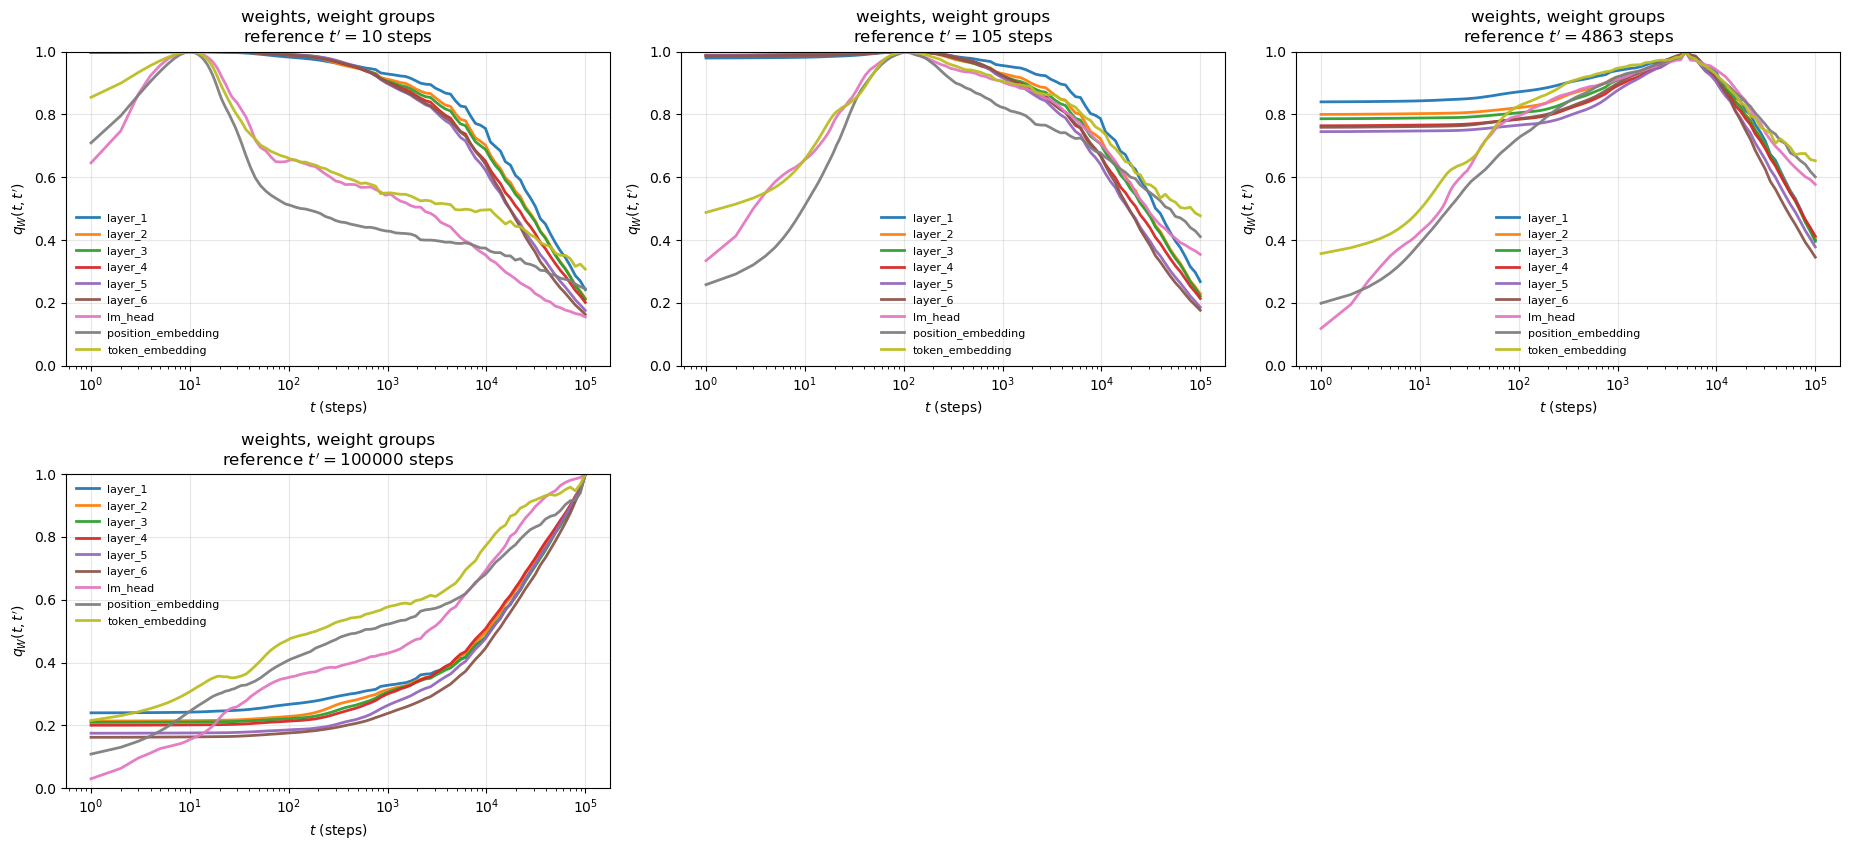

In [9]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_TR2_L3_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

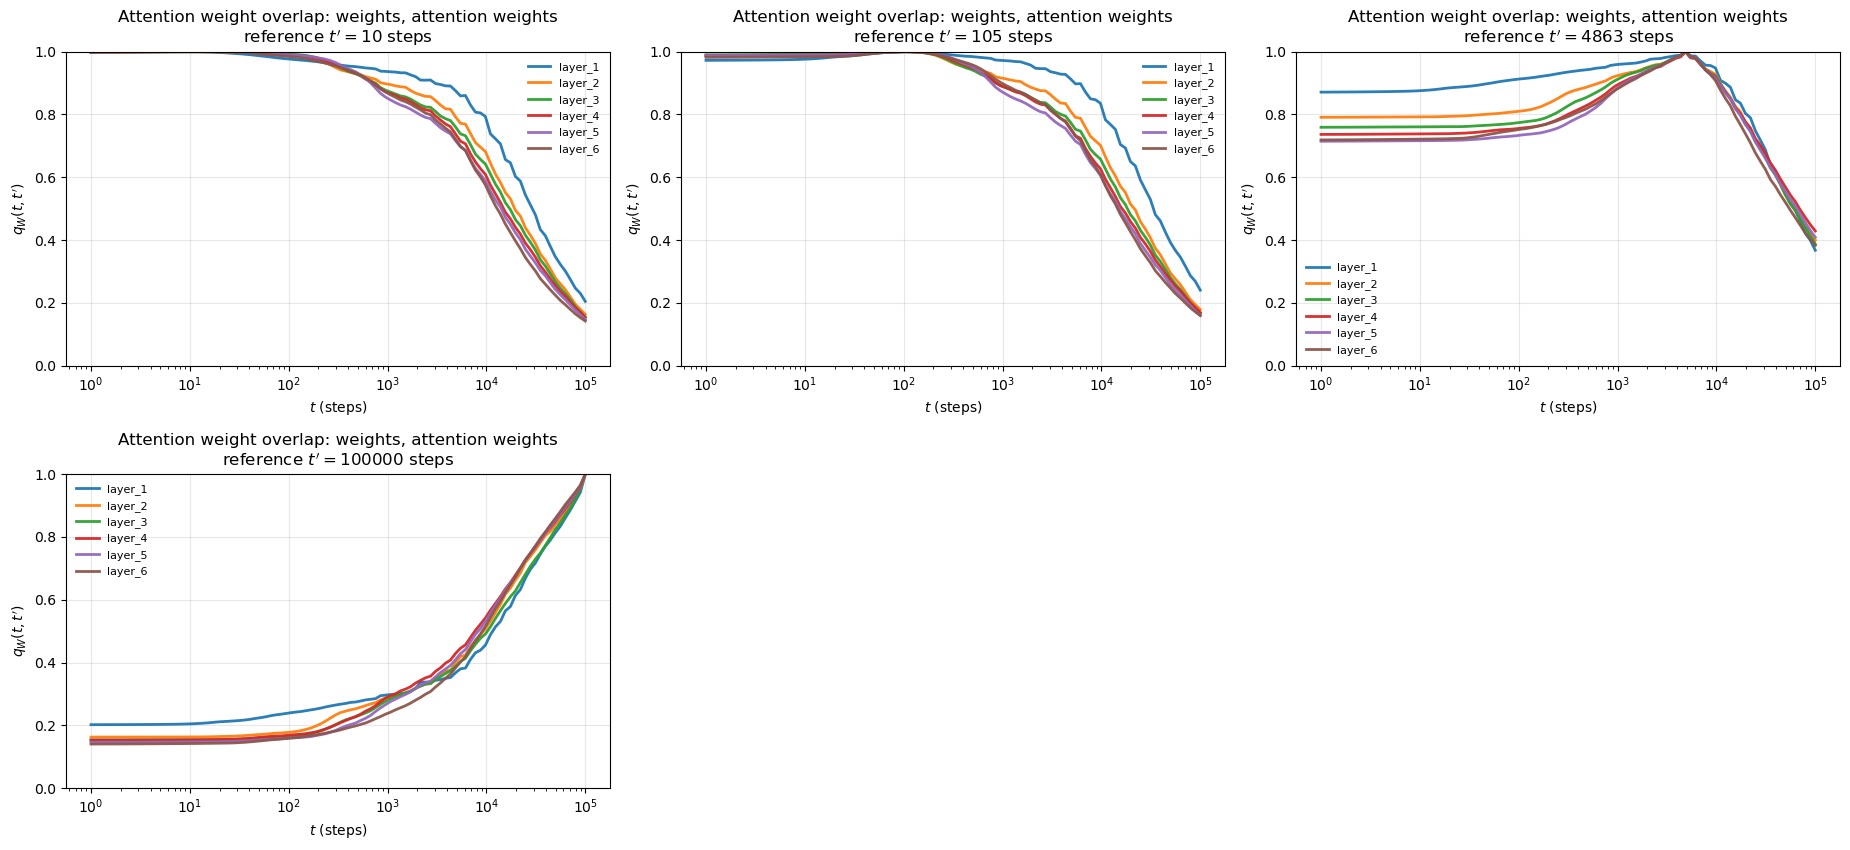

In [10]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_TR2_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

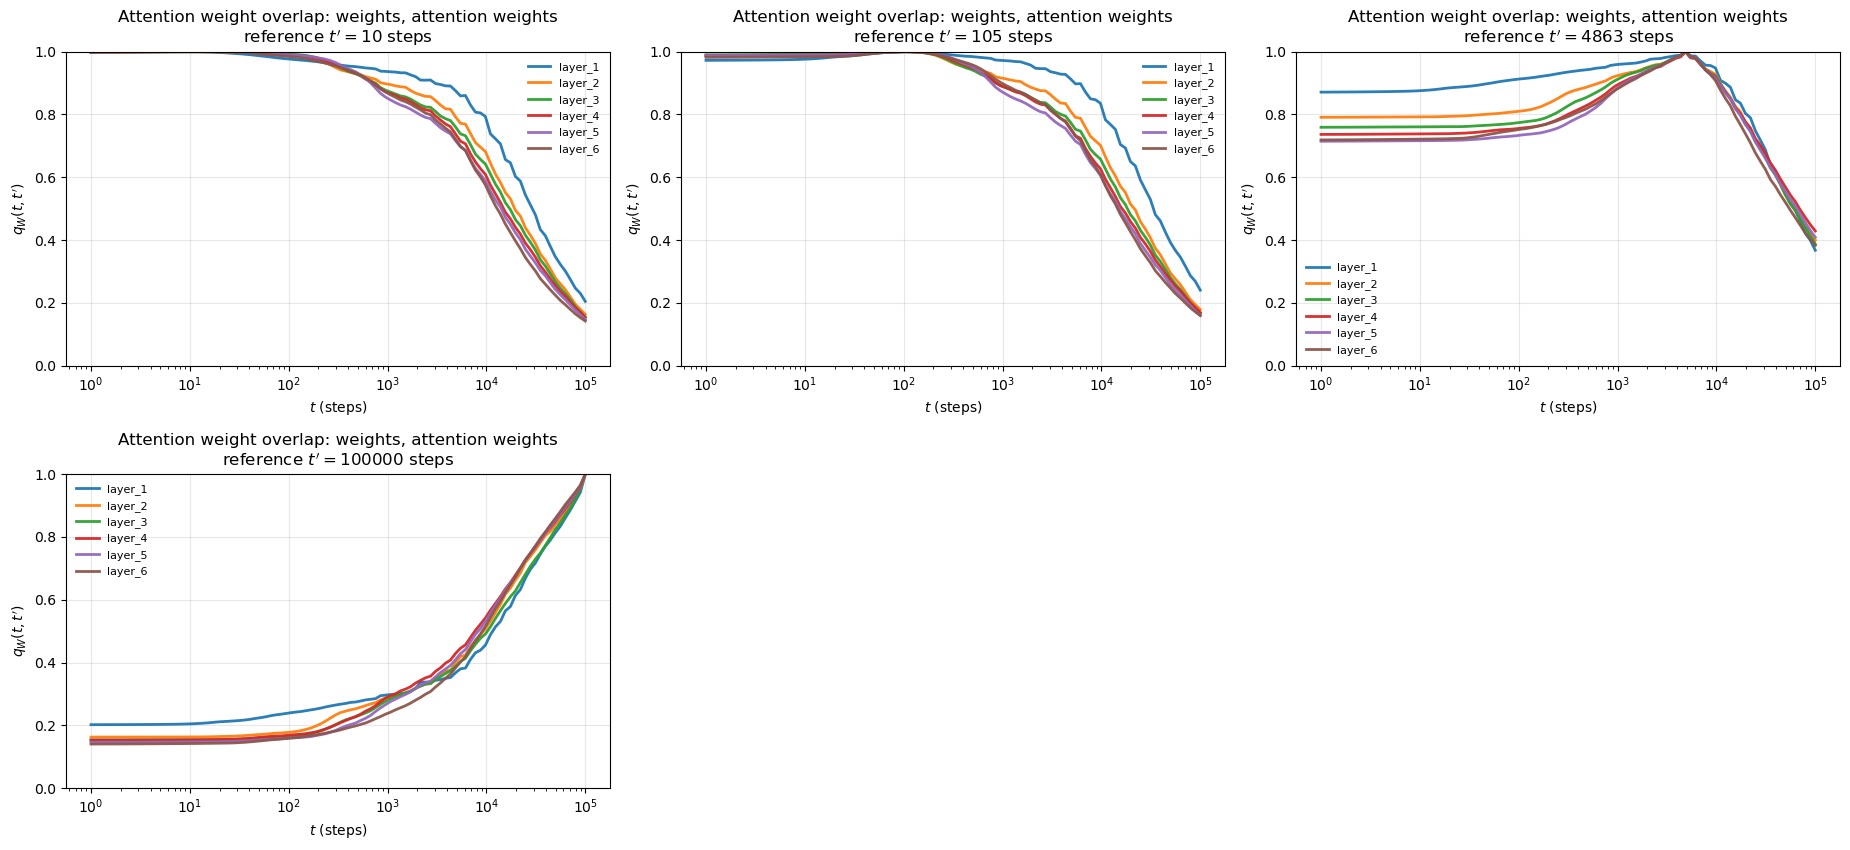

In [11]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_TR2_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

## L=3, v1

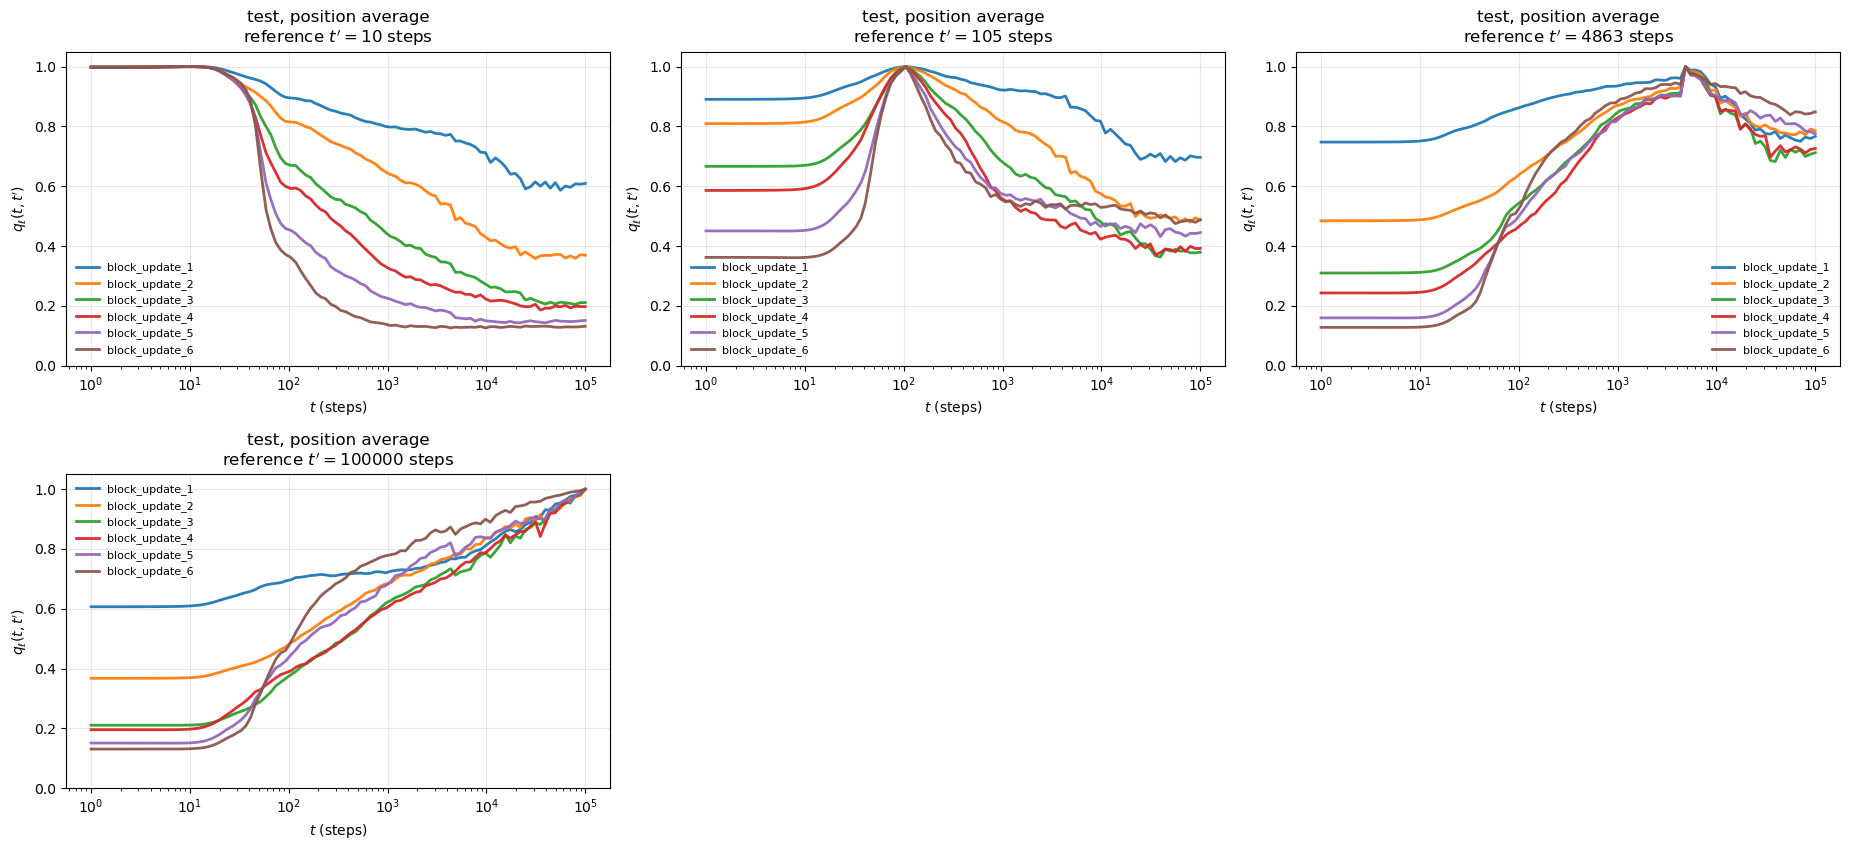

In [13]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_stream_L3_v1/",
    #output_name="",
    overlap_target="representations",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

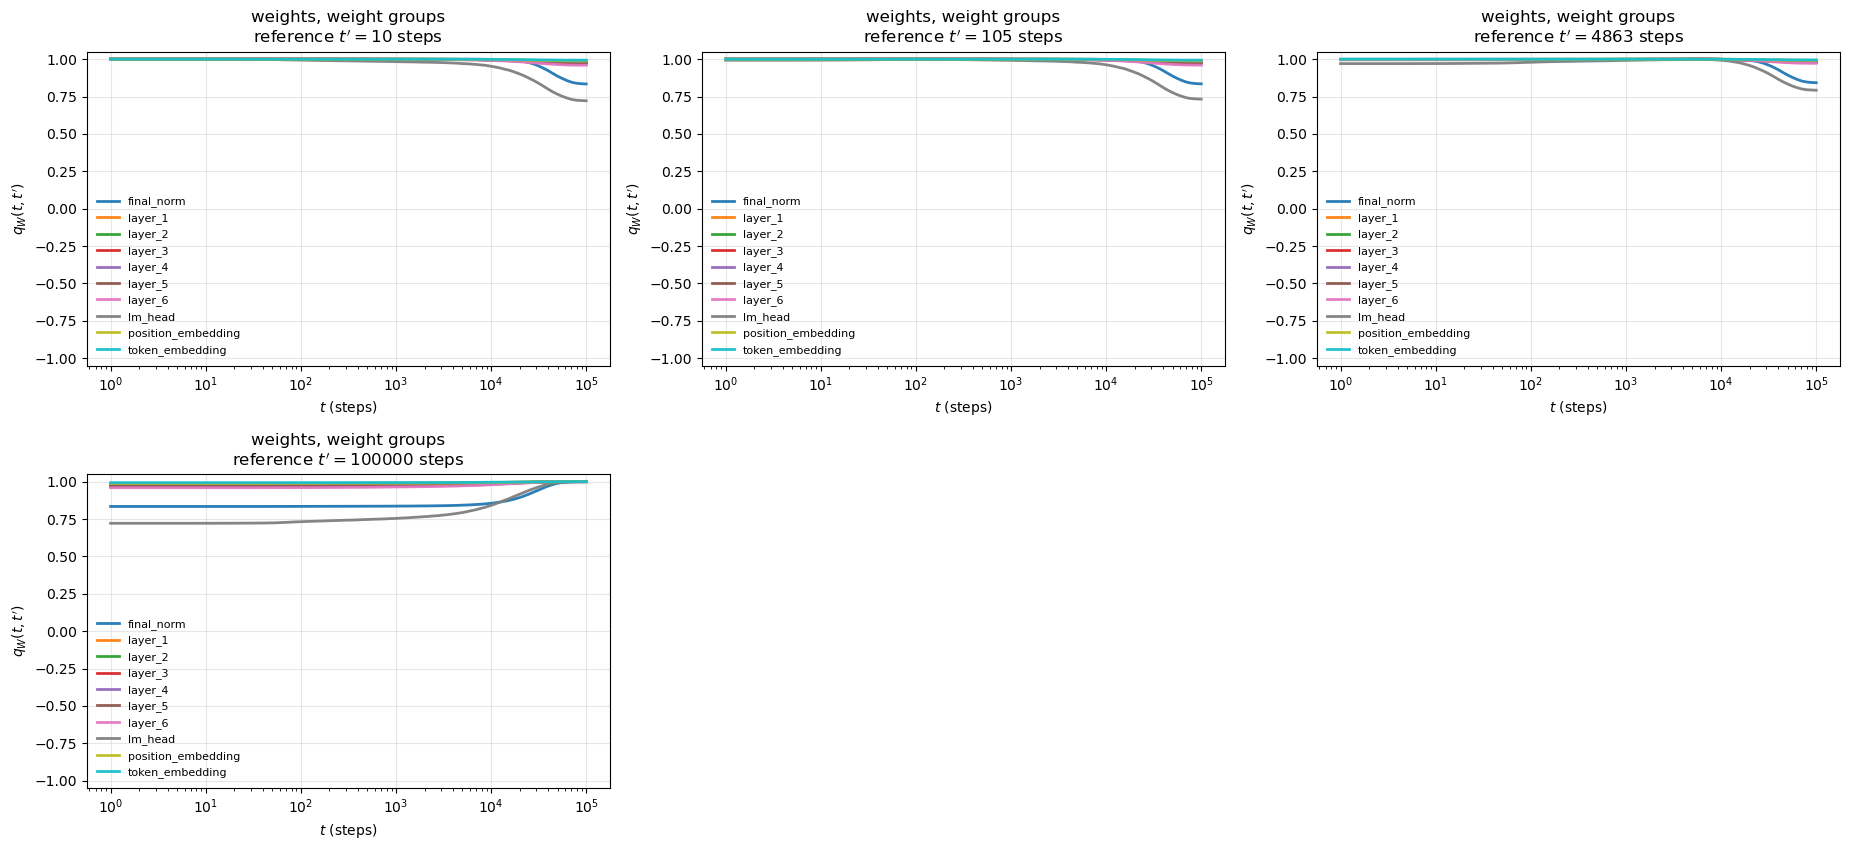

In [6]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_L3_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

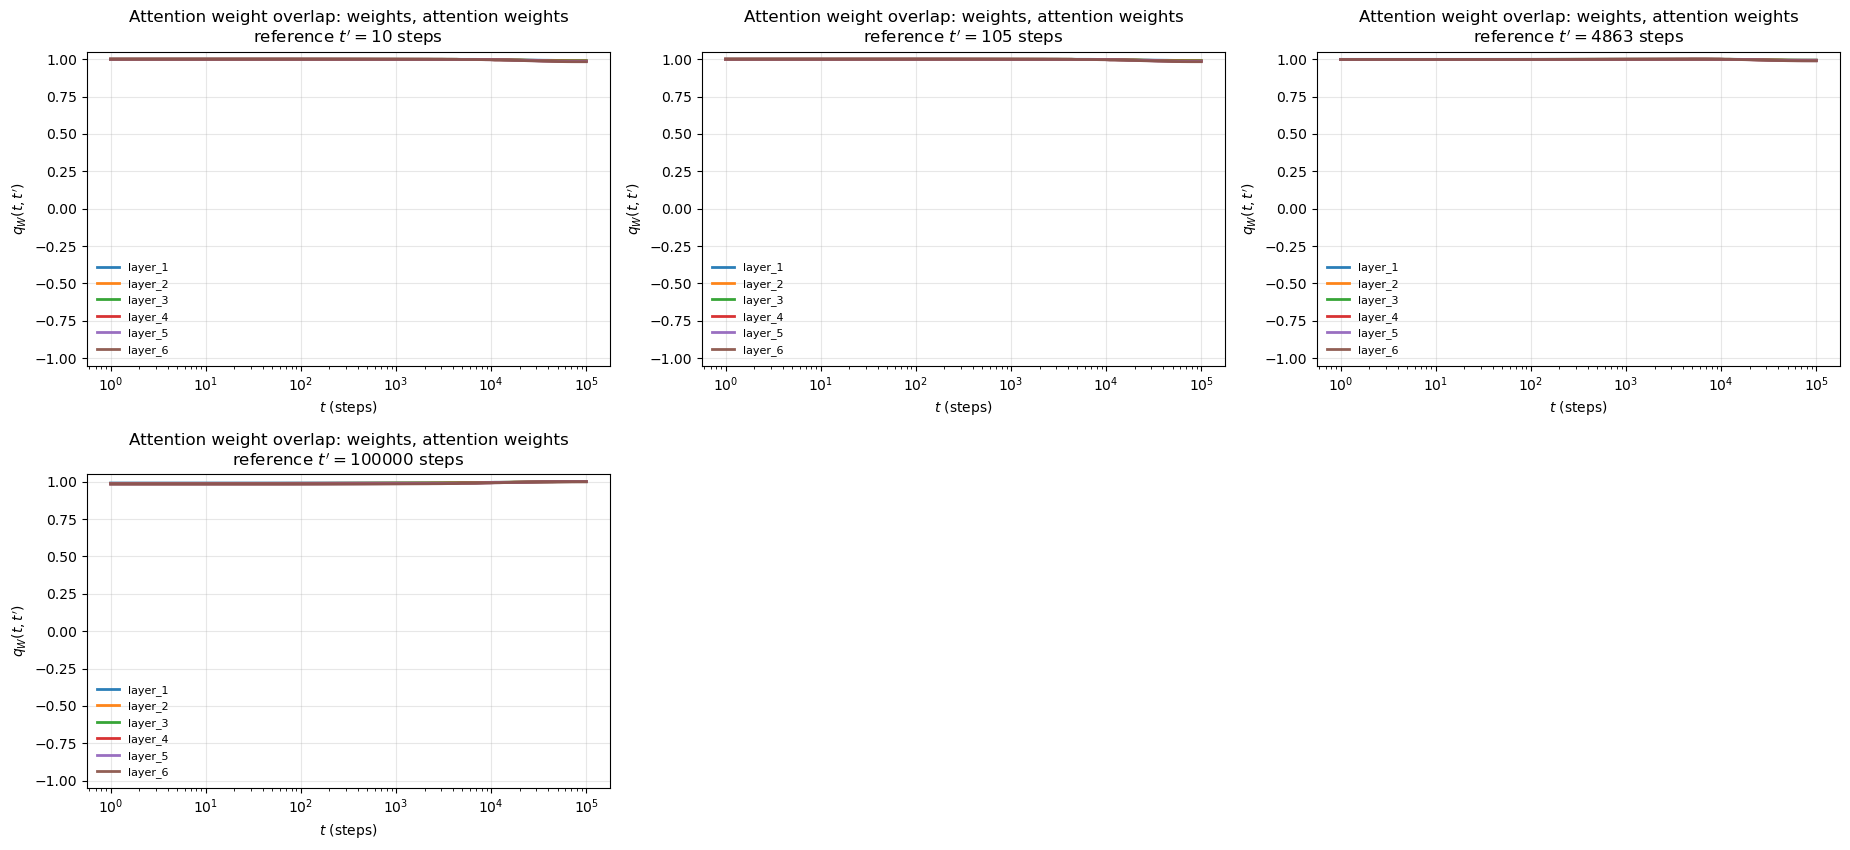

In [8]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

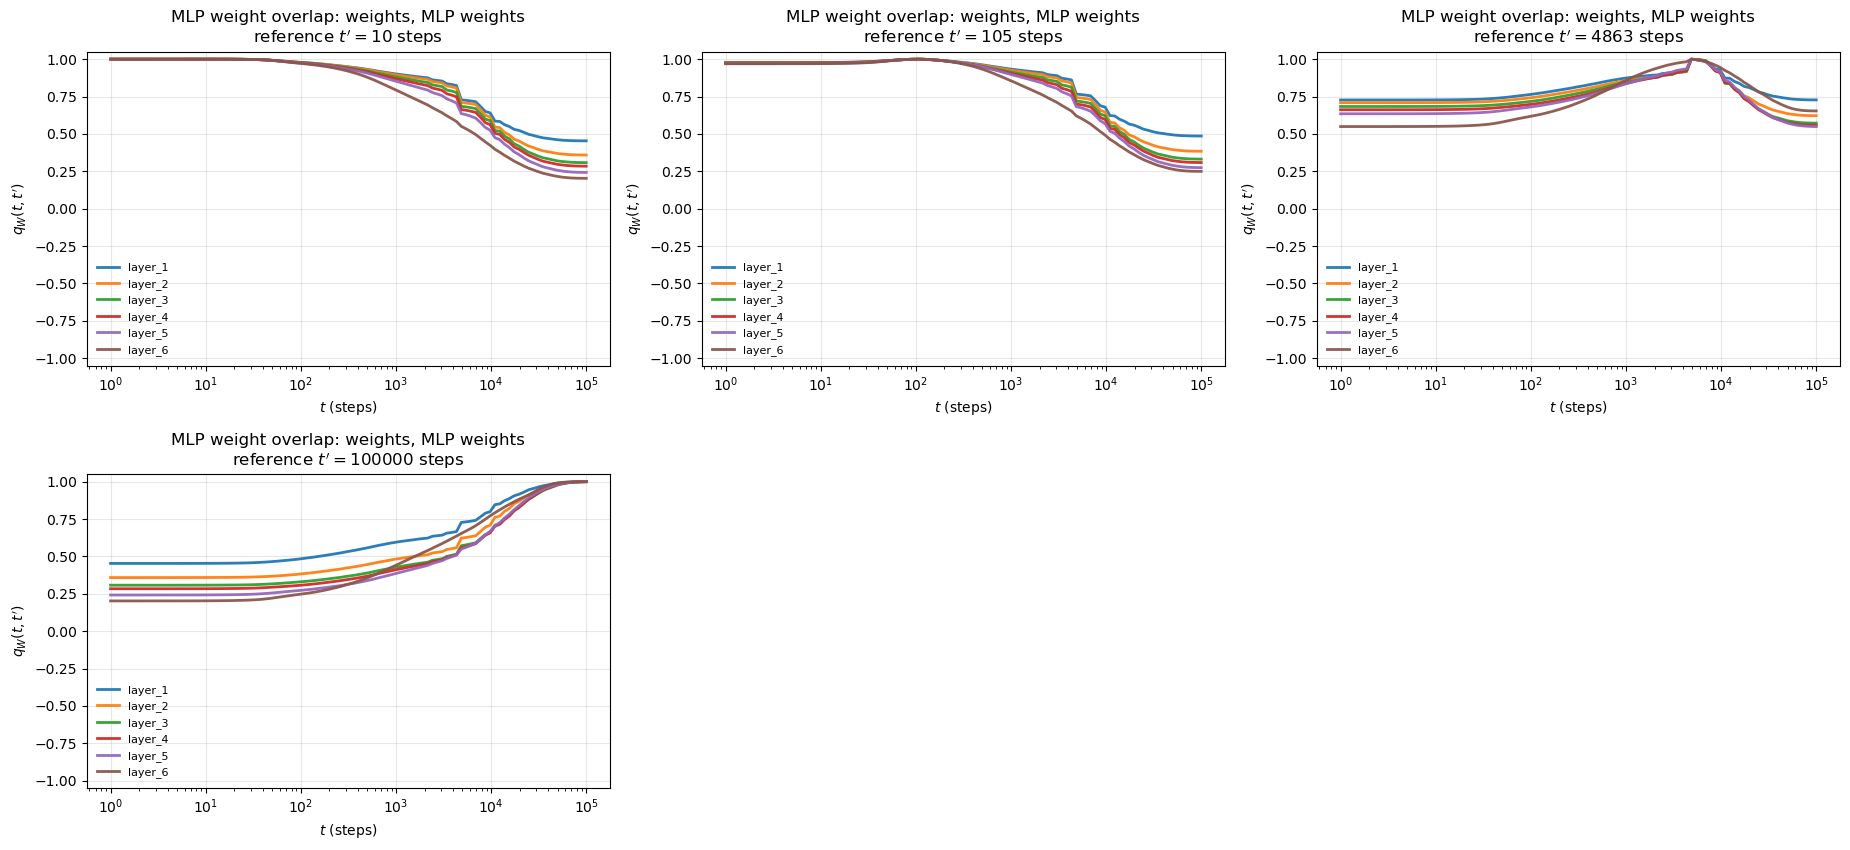

In [9]:
fig_mlp, axs_mlp, info_mlp = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L3_v1/"
    ),
    overlap_target="weights",

    weight_level="mlp",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="MLP weight overlap",
)

## L=4

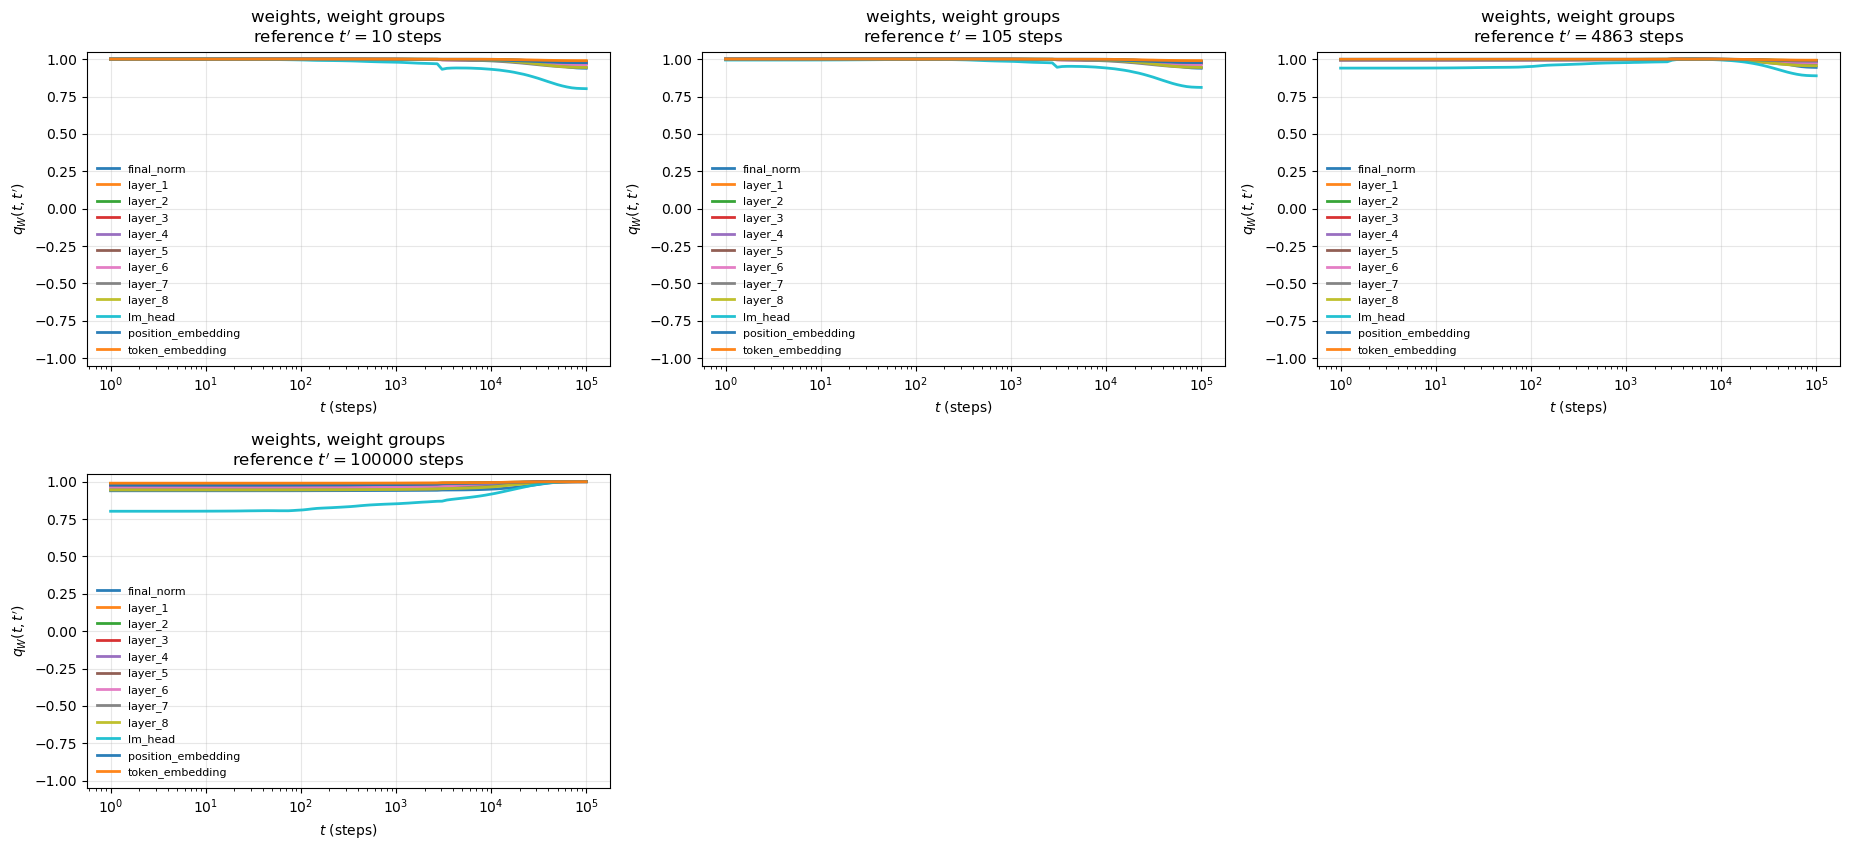

In [4]:
fig, axs, info = plot_ntp_representation_self_overlap_vs_time(
    results_dir="/mnt/beegfs/2a/mb12724/franc/small-language-modelling/collected_results/overlap_weights_L4_v1/",
    #output_name="",
    overlap_target="weights",

    split="test",
    position="mean",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,
)

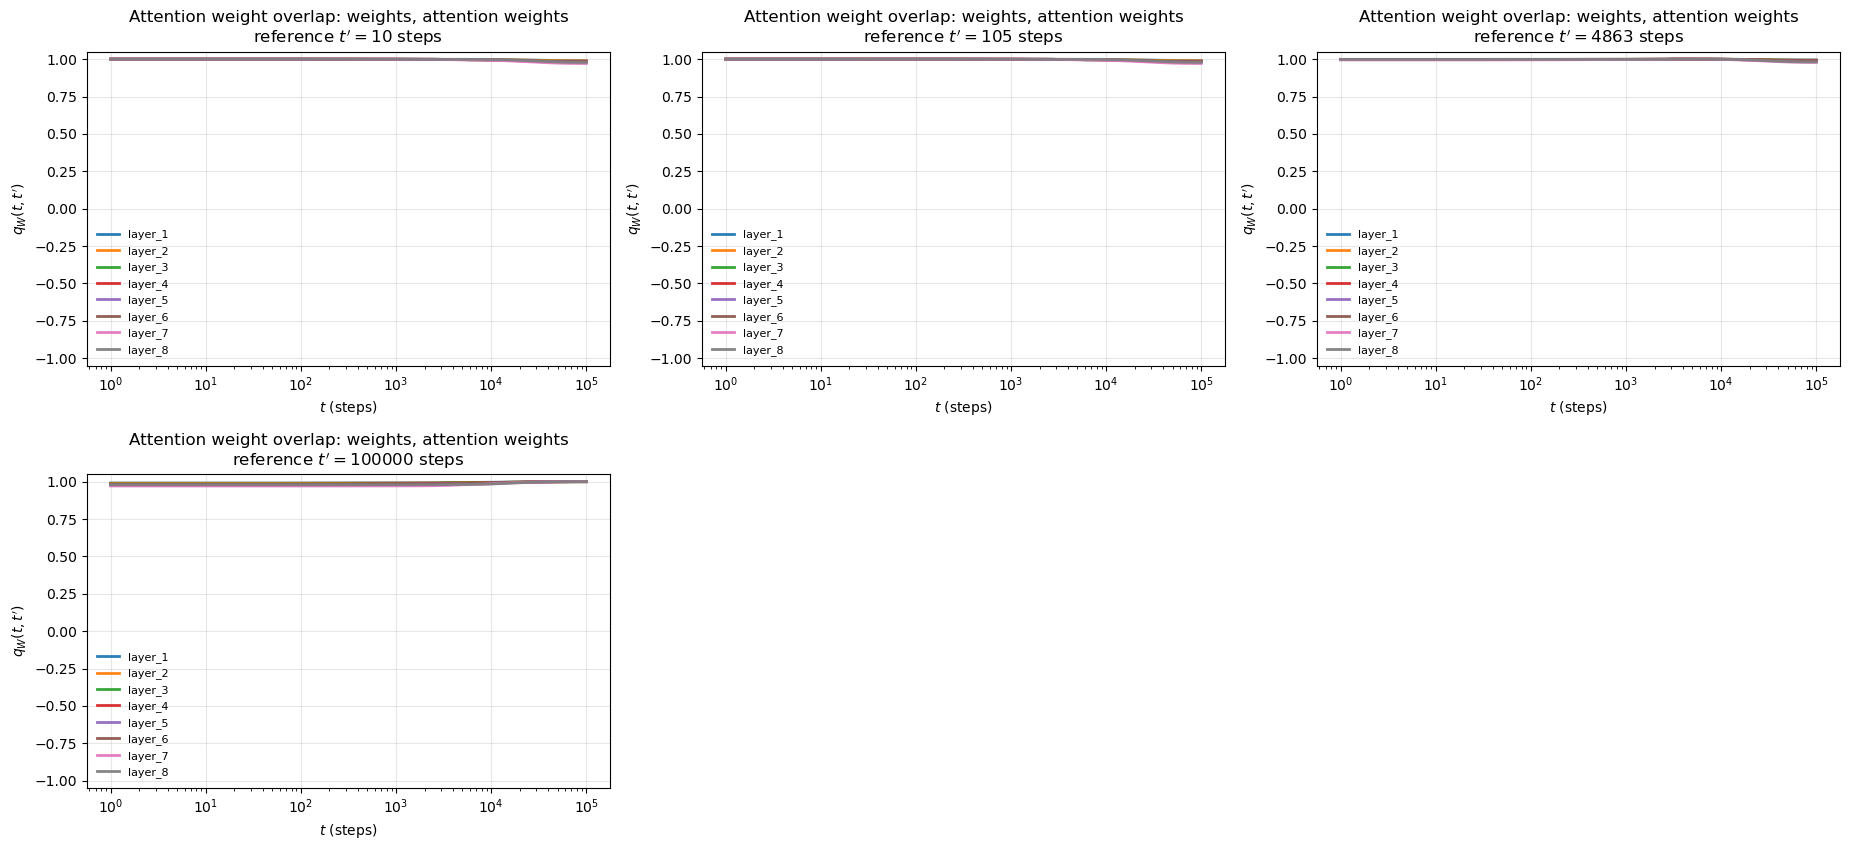

In [7]:
fig_attn, axs_attn, info_attn = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L4_v1/"
    ),
    overlap_target="weights",

    weight_level="attention",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="Attention weight overlap",
)

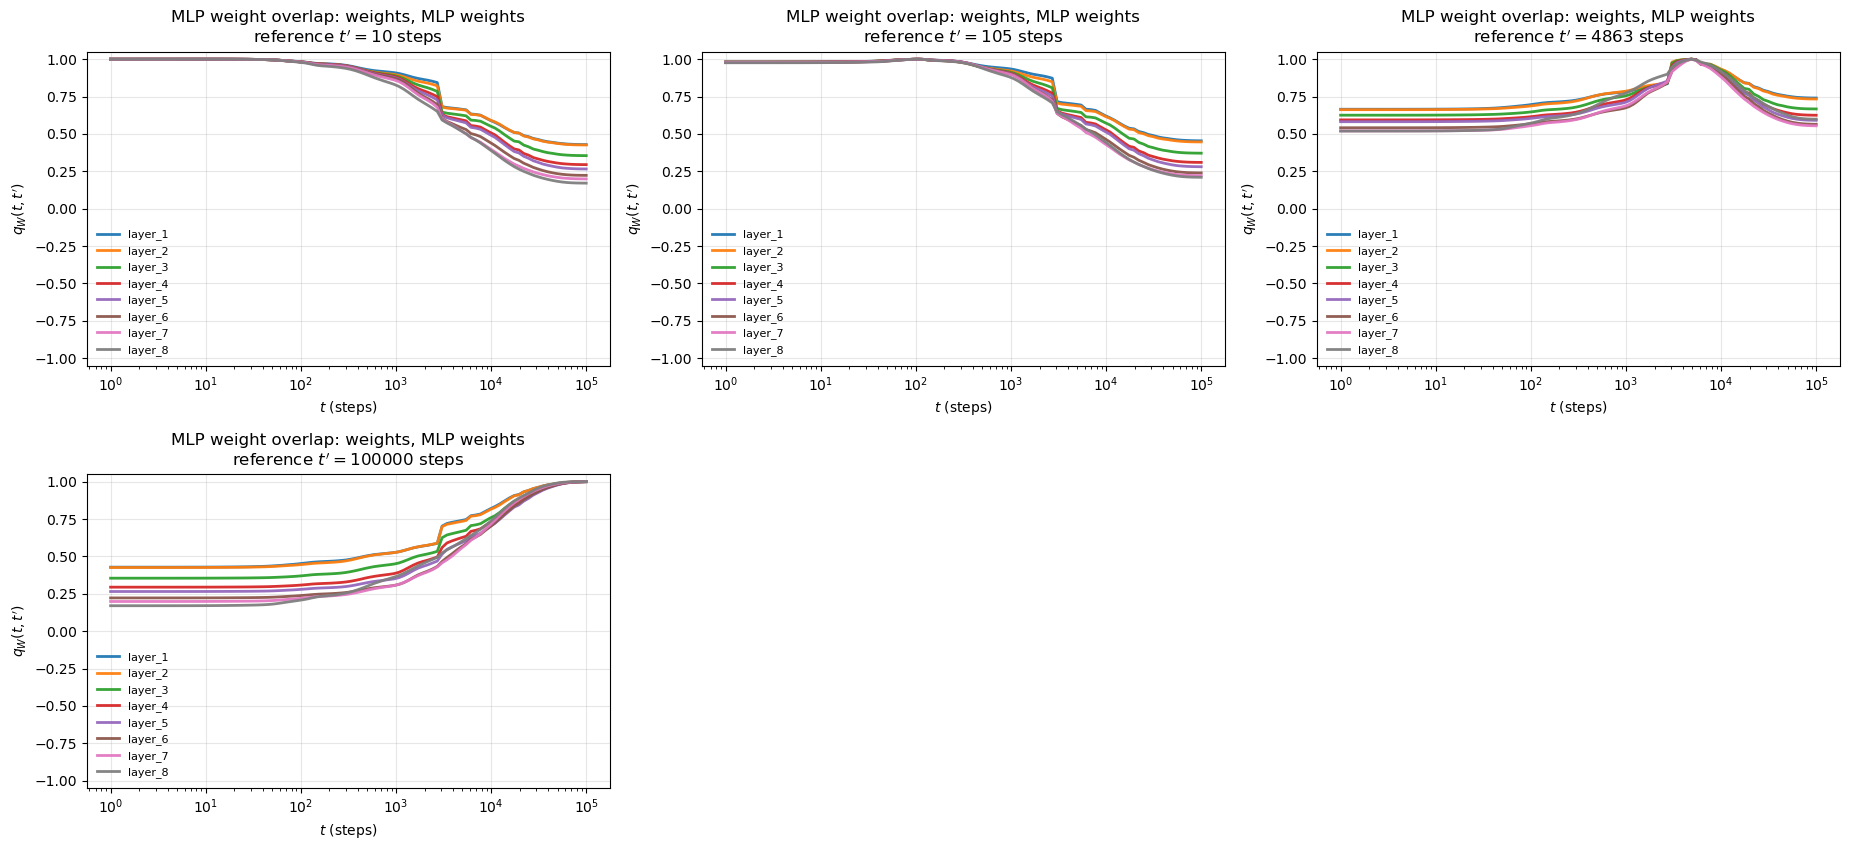

In [8]:
fig_mlp, axs_mlp, info_mlp = plot_ntp_representation_self_overlap_vs_time(
    results_dir=(
        "/mnt/beegfs/2a/mb12724/franc/"
        "small-language-modelling/collected_results/"
        "overlap_weights_L4_v1/"
    ),
    overlap_target="weights",

    weight_level="mlp",

    reference_times=[10, 100, 5000, 100000],
    time_key="steps",

    x_mode="absolute",
    xscale="log",
    only_t_ge_tprime=False,

    title_prefix="MLP weight overlap",
)